In [1]:
import numpy as np
import matplotlib.pyplot as pl
import time
import pyfftw
import scipy as sp
import finufft

In [2]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

This resampling is for a waveform from a PBH binary inspiral

In [3]:
f0 = 120
Mc = 3e-4* 2e30
f_max = 200
T_obs = 1e4
pad_len = int(323.4*T_obs) #~0.01 added length to resampled data
beta = const*f0**(8/3)*Mc**(5/3)

f_signal = 40*f_max
nt = round(f_signal*T_obs)
t = np.arange(nt)/f_signal
f_ratio = 25

Generating signal and adding noise

In [5]:
phi = -6*pi/5*f0*(1-8./3.*beta*t)**(5/8)/beta
phi = np.mod(phi,2*pi)
signal = 1*np.exp(1j*phi)

nh = 0
noise = nh*np.random.normal(size = nt)
data = signal + noise

In [8]:
def strobo(beta, data, f_ratio):
    new_t = -3/5*(1-8/3*beta*t)**(5/8)/beta
    f_new = f_signal/f_ratio
    
    new_t *= f_new #changes the frequency to the new downsampled frequency (approximately, not exactly)
    floor_t = np.floor(new_t) #For some reason floor works better than round. Take it to the nearest time index which are integers
    idx = np.nonzero(np.diff(floor_t)) #The step that downsamples
    resampled = data[idx]
    t_out = (new_t[idx]-new_t[0])/f_new
    return (resampled, t_out)

In [9]:
pyfftw.interfaces.cache.enable()

In [10]:
pyfftw.import_wisdom((b'', b'', b'(fftw-3.2.2 fftwl_wisdom\n)\n'))

(False, False, True)

In [11]:
f_ratio = 25
out, t_out = strobo(beta, data, f_ratio)
temp = pyfftw.empty_aligned(len(out), dtype='complex64')
fft_out = pyfftw.empty_aligned(len(out), dtype='complex64')
temp[:] = out
fft_obj = pyfftw.FFTW(temp, fft_out, threads=4, flags=('FFTW_EXHAUSTIVE',))
corrected = sp.fft.fftshift(fft_obj())
freq_corrected = sp.fft.fftshift(sp.fft.fftfreq(len(t_out), d=t_out[1]-t_out[0]))
corrected = corrected[len(corrected)//2:]
resampled_power = np.abs(corrected/len(out))**2

freq_corrected = freq_corrected[len(freq_corrected)//2:]
nt_new = len(out)

In [39]:
def np_benchmarking():
    tic = time.time()
    f_ratio = 25
    out, t_out = strobo(beta, data, f_ratio)
    corrected = np.fft.fftshift(np.fft.fft(out))
    freq_corrected = np.fft.fftshift(np.fft.fftfreq(len(t_out), d=t_out[1]-t_out[0]))
    corrected = corrected[len(corrected)//2:]
    resampled_power = np.abs(corrected/len(out))**2

    freq_corrected = freq_corrected[len(freq_corrected)//2:]
    nt_new = len(out)
    toc = time.time()
    
def sp_benchmarking():
    tic = time.time()
    f_ratio = 25
    out, t_out = strobo(beta, data, f_ratio)
    corrected = sp.fft.fftshift(sp.fft.fft(out))
    freq_corrected = sp.fft.fftshift(sp.fft.fftfreq(len(t_out), d=t_out[1]-t_out[0]))
    corrected = corrected[len(corrected)//2:]
    resampled_power = np.abs(corrected/len(out))**2

    freq_corrected = freq_corrected[len(freq_corrected)//2:]
    nt_new = len(out)
    toc = time.time()
    
def fftw_benchmarking(thread_no = 1):
    f_ratio = 25
    out, t_out = strobo(beta, data, f_ratio)
    temp = pyfftw.empty_aligned(len(out), dtype='complex64')
    fft_out = pyfftw.empty_aligned(len(out), dtype='complex64')
    temp[:] = out
    fft_obj = pyfftw.FFTW(temp, fft_out, threads=thread_no, flags = ('FFTW_DESTROY_INPUT',))
    corrected = np.fft.fftshift(fft_obj())
    freq_corrected = np.fft.fftshift(np.fft.fftfreq(len(t_out), d=t_out[1]-t_out[0]))
    corrected = corrected[len(corrected)//2:]
    resampled_power = np.abs(corrected/len(out))**2

    freq_corrected = freq_corrected[len(freq_corrected)//2:]
    nt_new = len(out)
    toc = time.time
    
def finufft_benchmarking(bin_ratio=1, eps=1e-6):
    tic = time.time()
    bin_no = int(len(data)/bin_ratio)
    bins = np.arange(bin_no) - bin_no//2
    tau = -3/5*(1-8/3*beta*t)**(5/8)/beta
    scale = (2*pi)/(tau[-1]-tau[0])
    tau *= scale
    start_diff = -pi-tau[0]
    tau += start_diff
    f = finufft.nufft1d1(tau.astype(np.float64), data.astype(complex), bin_no, eps=eps)
    toc = time.time()
    return (toc-tic)

In [13]:
%timeit fftw_benchmarking(thread_no=4)

1.95 s ± 6.09 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [14]:
%timeit fftw_benchmarking(thread_no=12)

1.96 s ± 6.97 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [15]:
%timeit np_benchmarking()

2.69 s ± 8.69 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [16]:
%timeit sp_benchmarking()

2.32 s ± 13.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [17]:
%timeit finufft_benchmarking(bin_ratio=1)
# It's actually slower if we take the oversampled data

6.31 s ± 108 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [18]:
%timeit finufft_benchmarking(bin_ratio=40/3)
# Oversampled data but fewer bins

3.08 s ± 85.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [41]:
# Need to make the signal with lower sampling rate

f0 = 20
Mc = 3e-4* 2e30
f_max = 200
T_obs = 1e4
pad_len = int(323.4*T_obs) #~0.01 added length to resampled data
beta = const*f0**(8/3)*Mc**(5/3)

f_signal = 3*f_max
nt = round(f_signal*T_obs)
t = np.arange(nt)/f_signal
f_ratio = 25
phi = -6*pi/5*f0*(1-8./3.*beta*t)**(5/8)/beta
phi = np.mod(phi,2*pi)
signal = 1*np.exp(1j*phi)

nh = 0
noise = nh*np.random.normal(size = nt)
data = signal + noise

In [42]:
%timeit finufft_benchmarking(bin_ratio=1)
# 3x faster if we use the lower sampling rate permitted
# Still faster than finufft with few bins

696 ms ± 29.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [45]:
%timeit finufft_benchmarking(bin_ratio=1, eps=1e-10)
# eps doesn't seem to have a large effect

719 ms ± 58.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Does it scale as NlogN

In [26]:
# Need to make the signal with lower sampling rate

Tspace = np.logspace(3, 5, 100)
compTime_arr = []
for i in Tspace:
    f_signal = 3*f_max
    nt = round(f_signal*i)
    t = np.arange(nt)/f_signal
    phi = -6*pi/5*f0*(1-8./3.*beta*t)**(5/8)/beta
    phi = np.mod(phi,2*pi)
    signal = 1*np.exp(1j*phi)
    noise = 0
    data = signal + noise
    comp_time = np.average([finufft_benchmarking(bin_ratio=1) for i in range(10)])
    compTime_arr.append(comp_time)

Text(0.5, 1.0, 'finufft: computational time vs number of points')

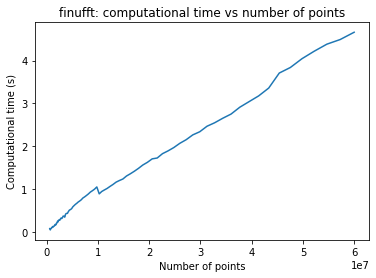

In [36]:
pl.plot(Tspace*f_signal, np.multiply(compTime_arr,60))
pl.ylabel("Computational time (s)")
pl.xlabel("Number of points")
pl.title("finufft: computational time vs number of points")

Text(0.5, 1.0, 'finufft: computational time vs number of points')

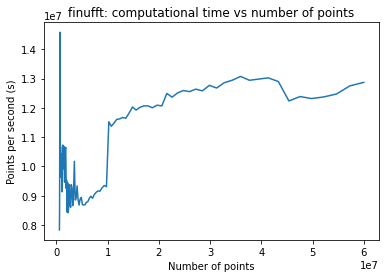

In [38]:
pl.plot(Tspace*f_signal, (Tspace*f_signal)/np.multiply(compTime_arr,60))
pl.ylabel("Points per second (s)")
pl.xlabel("Number of points")
pl.title("finufft: computational time vs number of points")

In [30]:
fit = np.polyfit(Tspace, np.multiply(compTime_arr,60), deg=1)

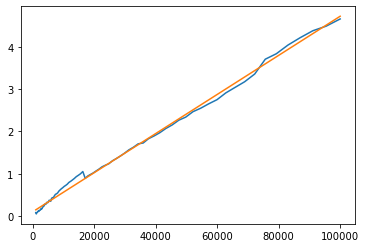

In [31]:
pl.plot(Tspace, np.multiply(compTime_arr,60))
pl.plot(Tspace, fit[0]*Tspace+fit[1])